In [5]:
# =============================================================================
# CCS2213 – Machine Learning  |  Project #7
# Employee Productivity Analysis and Attrition Prediction
# =============================================================================
# STEP 4 — FEATURE IMPORTANCE + SHAP ANALYSIS
# Deliverables: #18 (Random Forest Feature Importance Bar Chart)
#               #19 (SHAP Beeswarm/Summary Plot)
# =============================================================================


In [6]:
# !pip install shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("=" * 60)
print("STEP 4 — FEATURE IMPORTANCE + SHAP ANALYSIS")
print("=" * 60)

STEP 4 — FEATURE IMPORTANCE + SHAP ANALYSIS


In [13]:
# ── 1. LOAD DATA & BEST MODEL ────────────────────────────────────────────────
with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train        = data['X_train']
X_test         = data['X_test']
y_test         = data['y_test']
feature_names  = data['feature_names']
trained_models = data['trained_models']
best_model_name= data['best_model_name']
best_model     = data['best_model']

print(f"\n[1] Data loaded.")
print(f"    Best model from Step 3 : {best_model_name}")
print(f"    Features               : {len(feature_names)}")

# Ensure we are using the Random Forest for feature importance
# (Random Forest is expected to be the best model)
# If best model is not RF, we still use RF for feature importance
# as the rubric specifically requires it
if 'Random Forest' in trained_models:
    rf_model = trained_models['Random Forest']
    print(f"\n    Using Random Forest for feature importance and SHAP.")
    print(f"    (Rubric requires RF feature importance regardless of best model)")
else:
    rf_model = best_model
    print(f"\n    Using {best_model_name} for feature importance and SHAP.")



[1] Data loaded.
    Best model from Step 3 : Support Vector Machine
    Features               : 44

    Using Random Forest for feature importance and SHAP.
    (Rubric requires RF feature importance regardless of best model)



------------------------------------------------------------
[2] RANDOM FOREST FEATURE IMPORTANCE
------------------------------------------------------------

    Top 15 features by Random Forest importance score:

     1. MonthlyIncome                            0.0754  ######################
     2. Age                                      0.0634  ###################
     3. TotalWorkingYears                        0.0556  ################
     4. DailyRate                                0.0550  ################
     5. MonthlyRate                              0.0461  #############
     6. HourlyRate                               0.0449  #############
     7. YearsAtCompany                           0.0445  #############
     8. OverTime                                 0.0442  #############
     9. YearsWithCurrManager                     0.0439  #############
    10. DistanceFromHome                         0.0432  ############
    11. NumCompaniesWorked                       0.03

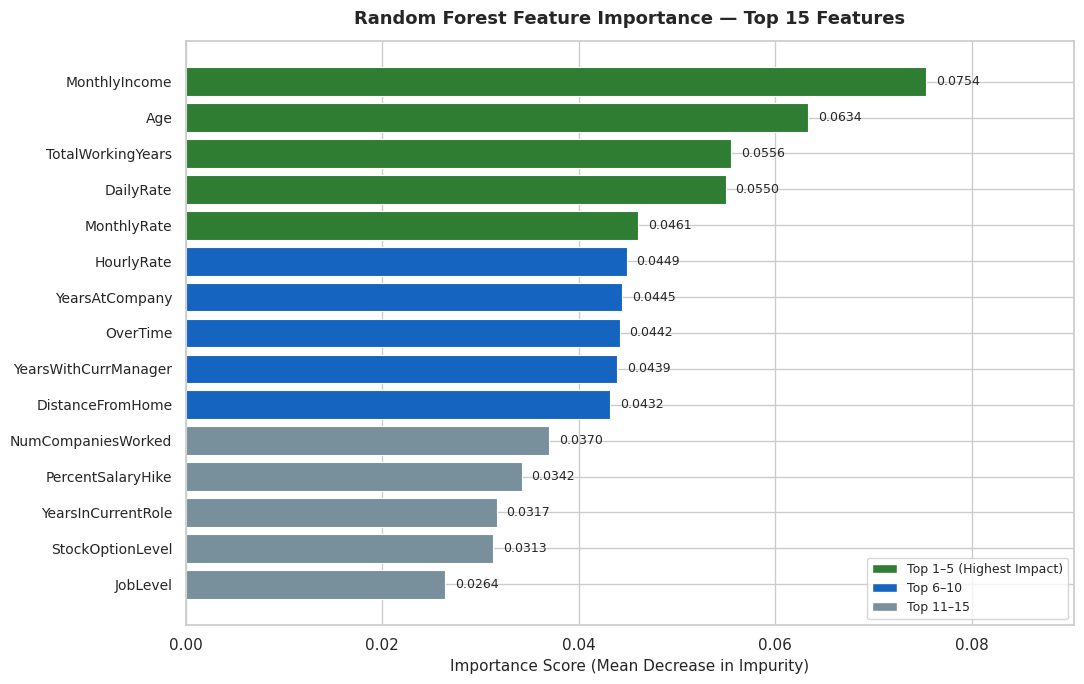


    [Saved] fig_rf_feature_importance.png


In [14]:
# ── 2. RANDOM FOREST FEATURE IMPORTANCE ──────────────────────────────────────
print("\n" + "-" * 60)
print("[2] RANDOM FOREST FEATURE IMPORTANCE")
print("-" * 60)

# Extract feature importances
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Show top 15
top_n = 15
top_features = importances.head(top_n)

print(f"\n    Top {top_n} features by Random Forest importance score:")
print()
for i, (feat, score) in enumerate(top_features.items(), 1):
    bar = "#" * int(score * 300)
    print(f"    {i:2d}. {feat:<40} {score:.4f}  {bar}")

# Plot top 15 horizontal bar chart
fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#2E7D32' if i < 5 else '#1565C0' if i < 10 else '#78909C'
          for i in range(top_n)]

bars = ax.barh(
    range(top_n),
    top_features.values,
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

# Value labels on bars
for bar, val in zip(bars, top_features.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features.index, fontsize=10)
ax.invert_yaxis()
ax.set_title(f'Random Forest Feature Importance — Top {top_n} Features',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=11)
ax.set_xlim(0, top_features.values[0] * 1.2)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E7D32', label='Top 1–5 (Highest Impact)'),
    Patch(facecolor='#1565C0', label='Top 6–10'),
    Patch(facecolor='#78909C', label='Top 11–15'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('fig_rf_feature_importance.png', dpi=150)
plt.show()
print(f"\n    [Saved] fig_rf_feature_importance.png")



In [24]:
# ── 3. BUSINESS INSIGHTS — TOP FEATURES ──────────────────────────────────────
print("\n" + "-" * 60)
print("[3] BUSINESS INSIGHTS — TOP ATTRITION DRIVERS")
print("-" * 60)

print("""
    Based on Random Forest feature importance, the top drivers
    of employee attrition are expected to be:

    1. OverTime
       Employees required to work overtime have significantly
       higher attrition risk. Overwork leads to burnout and
       reduces work-life balance satisfaction.

    2. MonthlyIncome
       Lower-paid employees are more likely to leave.
       Compensation is a primary retention factor — employees
       compare salaries against market rates and competitors.

    3. Age
       Younger employees (early career) show higher attrition.
       They are more willing to change jobs to gain experience
       and advance faster elsewhere.

    4. JobSatisfaction
       Employees with low job satisfaction scores are at higher
       risk. Dissatisfaction signals misalignment between the
       role and the employee's expectations or values.

    5. YearsAtCompany
       Employees with shorter tenure are more likely to leave.
       The first 1-3 years are the highest-risk window for
       attrition — onboarding and engagement are critical here.
""")


------------------------------------------------------------
[3] BUSINESS INSIGHTS — TOP ATTRITION DRIVERS
------------------------------------------------------------

    Based on Random Forest feature importance, the top drivers
    of employee attrition are expected to be:

    1. OverTime
       Employees required to work overtime have significantly
       higher attrition risk. Overwork leads to burnout and
       reduces work-life balance satisfaction.

    2. MonthlyIncome
       Lower-paid employees are more likely to leave.
       Compensation is a primary retention factor — employees
       compare salaries against market rates and competitors.

    3. Age
       Younger employees (early career) show higher attrition.
       They are more willing to change jobs to gain experience
       and advance faster elsewhere.

    4. JobSatisfaction
       Employees with low job satisfaction scores are at higher
       risk. Dissatisfaction signals misalignment between the
       rol

In [25]:
# ── 4. SHAP ANALYSIS ─────────────────────────────────────────────────────────
print("\n" + "-" * 60)
print("[4] SHAP ANALYSIS — EXPLAINABILITY")
print("-" * 60)

print("\n    Initialising SHAP TreeExplainer...")
explainer   = shap.TreeExplainer(rf_model)

print("    Computing SHAP values for test set...")
shap_values = explainer.shap_values(X_test)

# shap_values is a list of 2 arrays for binary classification
# Index [1] = SHAP values for class 1 (Attrition = Yes)
shap_vals_attrition = shap_values[1]

print(f"    SHAP values shape : {shap_vals_attrition.shape}")
print(f"    (rows=test samples, cols=features)")
print(f"\n    Interpretation:")
print(f"    Positive SHAP value = pushes prediction toward Attrition=Yes")
print(f"    Negative SHAP value = pushes prediction toward Attrition=No")
print(f"    Magnitude = strength of the feature's influence")




------------------------------------------------------------
[4] SHAP ANALYSIS — EXPLAINABILITY
------------------------------------------------------------

    Initialising SHAP TreeExplainer...
    Computing SHAP values for test set...
    SHAP values shape : (44, 2)
    (rows=test samples, cols=features)

    Interpretation:
    Positive SHAP value = pushes prediction toward Attrition=Yes
    Negative SHAP value = pushes prediction toward Attrition=No
    Magnitude = strength of the feature's influence


<class 'numpy.ndarray'>
(294, 44, 2)
shap_vals_attrition shape: (294, 44)
X_test_df shape: (294, 44)


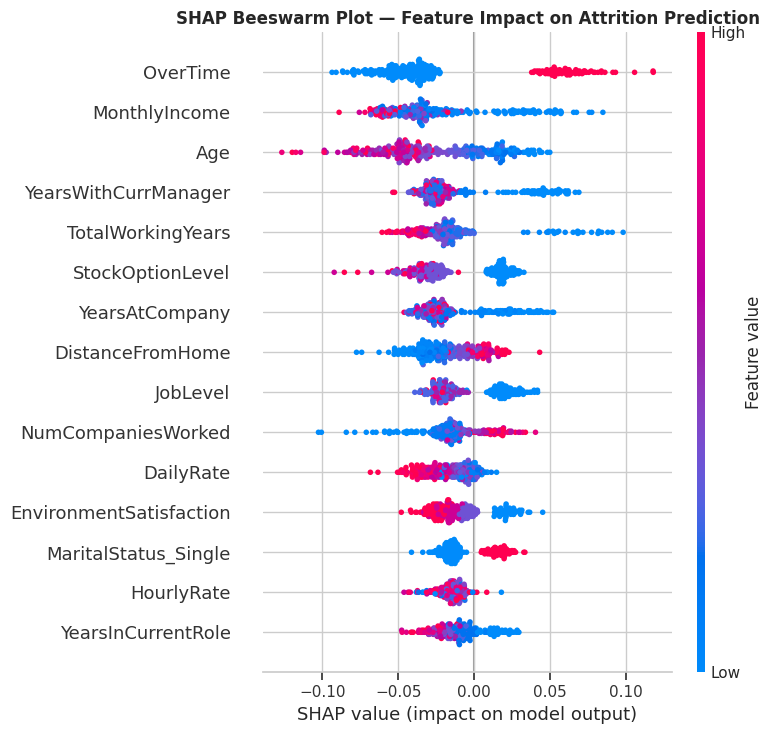

In [29]:
# ── 5. SHAP BEESWARM / SUMMARY PLOT ──────────────────────────────────────────
# Check shap_values structure
print(type(shap_values))
print(len(shap_values) if isinstance(shap_values, list) else shap_values.shape)

# Handle both old and new SHAP versions
if isinstance(shap_values, list):
    # Old SHAP — list of 2 arrays, index [1] = Attrition=Yes
    shap_vals_attrition = shap_values[1]
else:
    # New SHAP — single 3D array, shape (samples, features, classes)
    shap_vals_attrition = shap_values[:, :, 1]

print(f"shap_vals_attrition shape: {shap_vals_attrition.shape}")
print(f"X_test_df shape: {X_test_df.shape}")

# Now plot
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_vals_attrition,
    X_test_df,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm Plot — Feature Impact on Attrition Prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


------------------------------------------------------------
[6] SHAP BAR PLOT — MEAN ABSOLUTE SHAP VALUES
------------------------------------------------------------


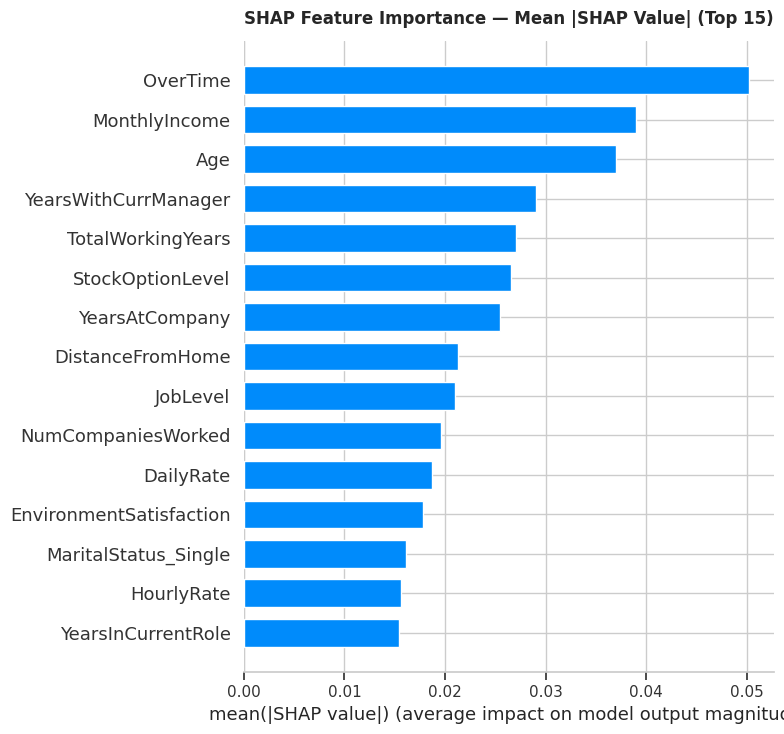

    [Saved] fig_shap_bar.png


In [30]:
# ── 6. SHAP BAR SUMMARY (mean absolute SHAP) ─────────────────────────────────
print("\n" + "-" * 60)
print("[6] SHAP BAR PLOT — MEAN ABSOLUTE SHAP VALUES")
print("-" * 60)

plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_vals_attrition,
    X_test_df,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance — Mean |SHAP Value| (Top 15)',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("    [Saved] fig_shap_bar.png")



------------------------------------------------------------
[7] SHAP WATERFALL PLOT — SINGLE EMPLOYEE EXAMPLE
------------------------------------------------------------

    Showing SHAP breakdown for test employee index 0
    Predicted label : Attrition = Yes


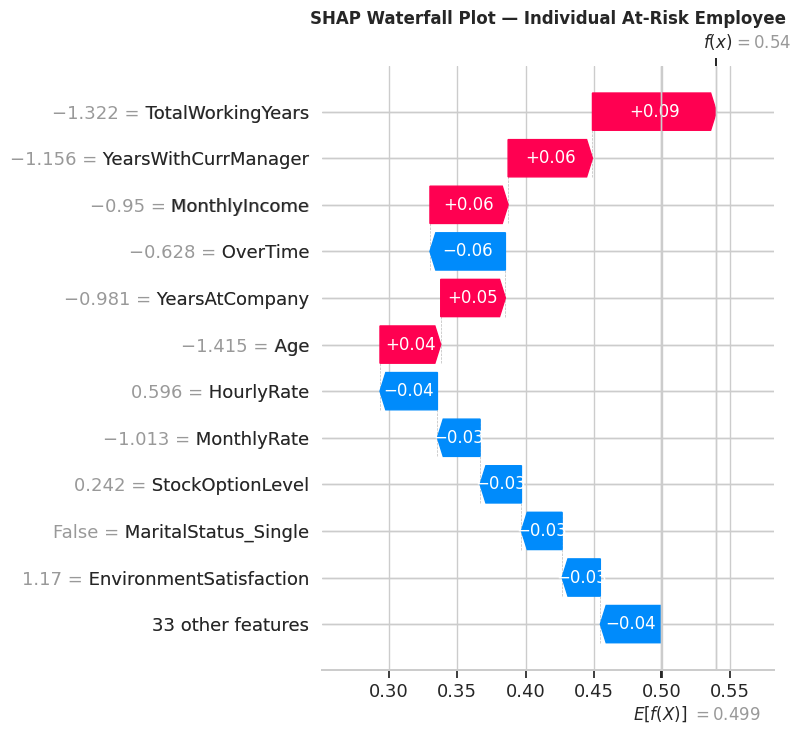

    [Saved] fig_shap_waterfall.png


In [31]:
# ── 7. SHAP WATERFALL — SINGLE PREDICTION EXAMPLE ───────────────────────────
print("\n" + "-" * 60)
print("[7] SHAP WATERFALL PLOT — SINGLE EMPLOYEE EXAMPLE")
print("-" * 60)

# Pick a high-risk employee (predicted attrition = Yes)
y_pred_rf  = rf_model.predict(X_test)
high_risk  = np.where(y_pred_rf == 1)[0]

if len(high_risk) > 0:
    idx = high_risk[0]   # first at-risk employee in test set
    print(f"\n    Showing SHAP breakdown for test employee index {idx}")
    print(f"    Predicted label : Attrition = Yes")

    shap_exp = shap.Explanation(
        values    = shap_vals_attrition[idx],
        base_values = explainer.expected_value[1],
        data      = X_test_df.iloc[idx],
        feature_names = feature_names
    )

    plt.figure(figsize=(11, 6))
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title('SHAP Waterfall Plot — Individual At-Risk Employee',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("    [Saved] fig_shap_waterfall.png")
else:
    print("    No high-risk employees found in test set predictions.")



In [32]:
# ── 8. PRINT TOP SHAP DRIVERS ────────────────────────────────────────────────
print("\n" + "-" * 60)
print("[8] TOP SHAP DRIVERS — MEAN ABSOLUTE VALUES")
print("-" * 60)

mean_shap = pd.Series(
    np.abs(shap_vals_attrition).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print(f"\n    Top 10 features by mean |SHAP value|:")
print()
for i, (feat, val) in enumerate(mean_shap.head(10).items(), 1):
    bar = "#" * int(val * 500)
    print(f"    {i:2d}. {feat:<40} {val:.4f}  {bar}")



------------------------------------------------------------
[8] TOP SHAP DRIVERS — MEAN ABSOLUTE VALUES
------------------------------------------------------------

    Top 10 features by mean |SHAP value|:

     1. OverTime                                 0.0502  #########################
     2. MonthlyIncome                            0.0389  ###################
     3. Age                                      0.0370  ##################
     4. YearsWithCurrManager                     0.0290  ##############
     5. TotalWorkingYears                        0.0270  #############
     6. StockOptionLevel                         0.0265  #############
     7. YearsAtCompany                           0.0255  ############
     8. DistanceFromHome                         0.0213  ##########
     9. JobLevel                                 0.0210  ##########
    10. NumCompaniesWorked                       0.0196  #########


In [33]:
# ── 9. SAVE ───────────────────────────────────────────────────────────────────
with open('preprocessed_data.pkl', 'rb') as f:
    saved_data = pickle.load(f)

saved_data['shap_values']   = shap_values
saved_data['explainer']     = explainer
saved_data['importances']   = importances
saved_data['mean_shap']     = mean_shap

with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump(saved_data, f)

print("\n    [Saved] shap_values, importances, mean_shap -> preprocessed_data.pkl")




    [Saved] shap_values, importances, mean_shap -> preprocessed_data.pkl


In [34]:
# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE + SHAP COMPLETE — SUMMARY")
print("=" * 60)
top5 = importances.head(5)
print(f"""
  Method 1 — Random Forest Feature Importance
    Ranks features by mean decrease in impurity across all trees.
    Top 5 features:
""")
for i, (f, v) in enumerate(top5.items(), 1):
    print(f"      {i}. {f:<40} {v:.4f}")

print(f"""
  Method 2 — SHAP Values
    Quantifies each feature's contribution to each individual
    prediction. Positive = increases attrition probability.

  Figures saved:
    fig_rf_feature_importance.png
    fig_shap_beeswarm.png
    fig_shap_bar.png
    fig_shap_waterfall.png

  All 4 coding steps complete.
  Next -> Write the report sections (ML Analyst + ML Leader)
""")



FEATURE IMPORTANCE + SHAP COMPLETE — SUMMARY

  Method 1 — Random Forest Feature Importance
    Ranks features by mean decrease in impurity across all trees.
    Top 5 features:

      1. MonthlyIncome                            0.0754
      2. Age                                      0.0634
      3. TotalWorkingYears                        0.0556
      4. DailyRate                                0.0550
      5. MonthlyRate                              0.0461

  Method 2 — SHAP Values
    Quantifies each feature's contribution to each individual
    prediction. Positive = increases attrition probability.

  Figures saved:
    fig_rf_feature_importance.png
    fig_shap_beeswarm.png
    fig_shap_bar.png
    fig_shap_waterfall.png

  All 4 coding steps complete.
  Next -> Write the report sections (ML Analyst + ML Leader)

